    Author(s): Daniel Tweneboah Anyimadu

FINETUNING

(01) Configure Paths

- Update the following variables in your .ipynb files:
  -"tr_dir" (training data directory - ensure it contains "HR" & "LR" folders with matching data pairs)
  - "pretrained_path" (pretrained weights path)
  - "checkpoint_path" (checkpoint/model weights path)

(02) Feel free to execute the code as it is.  

NB: Data dimensions must follow HR = 2 × LR (e.g., HR: 512×512 corresponds to LR: 256×256).

# Connecting Google Colab (Jupyter Notebook) & Google Drive:

To access the dataset.

In [33]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [ ]:
# EPOCH_COUNT = 30

# tr_dir =  "G:\\LF-7T-CycleGAN\\benchmarks\\SRDDL\\datasets\\LF-7T-Paired-Dataset-Train\\npy"

# # Pretrained model path
# pretrained_path = "G:\\LF-7T-CycleGAN\\benchmarks\\SRDDL\\weight\\srdd150E.pt"

# # Fine-tuned checkpoint save path
# checkpoint_path = "G:\\LF-7T-CycleGAN\\benchmarks\\SRDDL\\weight\\checkpoints-full-dataset-run.pt"


EPOCH_COUNT = 30

tr_dir =  "G:\\LF-7T-CycleGAN\\benchmarks\\SRDDL\\datasets\\T2w-LF-7T-Paired-Dataset-Train"

# Pretrained model path
pretrained_path = "G:\\LF-7T-CycleGAN\\benchmarks\\SRDDL\\weight\\srdd150E.pt"

# Fine-tuned checkpoint save path
checkpoint_path = "G:\\LF-7T-CycleGAN\\benchmarks\\SRDDL\\weight\\T2w-checkpoints-full-dataset-run.pt"

# **INSTALL PACKAGES & IMPORT LIBRARIES**

In [35]:
# Install packages
!pip install pillow matplotlib tqdm kornia scikit-image scipy lpips patchify torch torchvision opencv-python-headless pandas seaborn

In [36]:
from __future__ import annotations

# Libraries for exploratory data analysis (EDA)
%matplotlib inline
import os
import cv2
import random
import numpy as np
import pandas as pd
import seaborn as sns
from glob import glob
from tqdm import tqdm
from PIL import Image
from pathlib import Path
from scipy.io import loadmat
import matplotlib.pyplot as plt
from IPython.display import clear_output
from typing import List, Optional, Tuple

# Libraries for data preprocessing/preparation
from einops import rearrange
from scipy.ndimage import zoom
import kornia.augmentation as K
from dataclasses import dataclass
from numpy.fft import fft2, fftshift
from patchify import patchify, unpatchify
from einops.layers.torch import Rearrange
from scipy.fftpack import fftshift, ifftshift, ifftn, fftn
from sklearn.model_selection import KFold, train_test_split

# Libraries for AI model setup: PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, Subset

# Evalution metrics
import gc
import math
import lpips
import scipy.stats as stats
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim, mean_squared_error as mse

# Filter warnings
import warnings
warnings.filterwarnings("ignore")

___________________

# **(A): EXPLORATORY DATA ANALYSIS (EDA)**

# Training Dataset

In [37]:
# Define file paths for HR and LR dataset
HRdir = os.path.join(tr_dir, "HR")
LRdir = os.path.join(tr_dir, "LR")

# List files and sort them
HRfile = sorted([os.path.join(HRdir, file) for file in tqdm(os.listdir(HRdir)) if file.endswith(".npy")]) # [:1] 
LRfile = sorted([os.path.join(LRdir, file) for file in tqdm(os.listdir(LRdir)) if file.endswith(".npy")]) # [:1] 

# Create & display DataFrame
tr_df = pd.DataFrame({"HRfiles": HRfile,"LRfiles": LRfile})
tr_df.head()

  0%|          | 0/2920 [00:00<?, ?it/s]

100%|██████████| 2920/2920 [00:00<00:00, 118677.19it/s]


,HRfiles,LRfiles
0,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...
1,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...
2,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...
3,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...
4,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...,G:\LF-7T-CycleGAN\benchmarks\SRDDL\datasets\T2...


Plot Visualizations

HRimg Shape: (256, 256) || HRimg maxVal: 1.1164984703063965 || HRimg minVal: -1.0782395601272583
LRimg Shape: (128, 128) || LRimg maxVal: 0.9899799823760986 || LRimg minVal: -0.9379441738128662


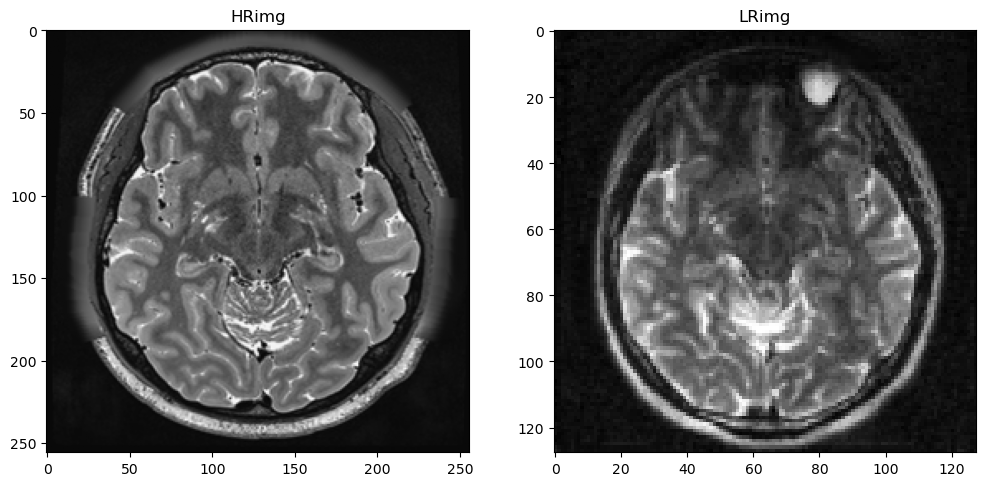

In [38]:
# Load the HRimg, and LRimg 
HRimg = np.load(tr_df["HRfiles"].iloc[0])
LRimg = np.load(tr_df["LRfiles"].iloc[0])

print(f"HRimg Shape: {HRimg.shape} || HRimg maxVal: {HRimg.max()} || HRimg minVal: {HRimg.min()}")
print(f"LRimg Shape: {LRimg.shape} || LRimg maxVal: {LRimg.max()} || LRimg minVal: {LRimg.min()}")

# Plot the HRimg, and LRimg side by side 
plt.figure(figsize=[12, 6])
plt.subplot(1, 2, 1); plt.imshow(HRimg, cmap='gray'); plt.title(f"HRimg") 
plt.subplot(1, 2, 2); plt.imshow(LRimg, cmap='gray'); plt.title(f"LRimg") 
plt.show()

___________________

# **(B): DATA PREPROCESSING/PREPARATION**

# Patch Extraction, Patch Reconstruction, & Scaling (On Training Dataset)

Functions for Patch Extraction, Patch Reconstruction, & Scaling

In [39]:
# Function to extract 2D patches from a slice
def patch(data, patch_size=(32, 32), step=16):
    """ Extracts patches from a 2D data. """
    patches = patchify(data, patch_size, step=step)
    return patches

# Function to reconstruct the full data from 2D patches
def unpatch(patches, data_shape):
    """ Reconstructs the 2D data from extracted patches. """
    reconstructed = unpatchify(patches, data_shape)
    return reconstructed

# Function to extract paired 2D patches
scale = 2; lr_patch_size = (32, 32); lr_step = 16
def pairedPatch(hr_img, lr_img, scale=scale, lr_patch_size=lr_patch_size, lr_step=lr_step):
    """Extract aligned LR/HR patches for super-resolution."""
    lr_ph, lr_pw = lr_patch_size
    hr_patch_size = (lr_ph * scale, lr_pw * scale)
    hr_step = lr_step * scale

    assert hr_img.shape[0] == lr_img.shape[0] * scale, f"H mismatch: {hr_img.shape} vs {lr_img.shape}"
    assert hr_img.shape[1] == lr_img.shape[1] * scale, f"W mismatch: {hr_img.shape} vs {lr_img.shape}"

    lr_patches = patch(lr_img, patch_size=lr_patch_size, step=lr_step)
    hr_patches = patch(hr_img, patch_size=hr_patch_size, step=hr_step)

    assert lr_patches.shape[:2] == hr_patches.shape[:2]
    return hr_patches, lr_patches

# Augmentations

In [40]:
# Horizontal Flip
def hFlip(image, target, prob=0.5):
    if random.random() < prob:
        image  = torch.flip(image, dims=[2])  # horizontal (W axis)
        target = torch.flip(target, dims=[2]) # horizontal (W axis)
    return image, target

# 90-degree rotation
def rot90(image, target, prob=0.5):
    if random.random() < prob:
        k = random.randint(0, 3)  # 0,1,2,3 → 0°,90°,180°,270°
        image  = torch.rot90(image, k, dims=[1, 2])
        target = torch.rot90(target, k, dims=[1, 2])
    return image, target

Apply Patch Extraction, Patch Reconstruction, & Scaling Functions

In [41]:
# Data Storage Lists (Separate Lists for Each Processed Item)
HR_imagesP = []; HR_imagesU = [] 
LR_imagesP = []; LR_imagesU = [] 

# Loop Through the DataFrame & Process Each Image
for hr_file, lr_file in tqdm(zip(tr_df["HRfiles"], tr_df["LRfiles"]), total=len(tr_df), desc="Processing Images"):

    # Load the HRimg, and LRimg
    HRimage = np.load(hr_file)
    LRimage = np.load(lr_file)

    # Extract 2D paired patches
    HRimgPatch, LRimgPatch = pairedPatch(hr_img=HRimage, lr_img=LRimage, scale=scale, lr_patch_size=lr_patch_size, lr_step=lr_step)

    # Reconstruct the full volume from patches
    HRimgUnpat = unpatch(HRimgPatch, HRimage.shape)
    LRimgUnpat = unpatch(LRimgPatch, LRimage.shape)

    HR_imagesP.append(HRimgPatch); HR_imagesU.append(HRimgUnpat); LR_imagesP.append(LRimgPatch); LR_imagesU.append(LRimgUnpat)

Processing Images: 100%|██████████| 2920/2920 [01:10<00:00, 41.36it/s]


Plot Visualizations

Dimensions of - fsHRimgP: (7, 7, 64, 64) || fsLRimgP: (7, 7, 32, 32)
Dimensions of - fsHRimgU: (256, 256) || fsLRimgU: (128, 128)

minVal of LR: -0.9379441738128662 || maxVal of LR: 0.9899799823760986
minVal of HR: -1.0782395601272583 || maxVal of HR: 1.1164984703063965


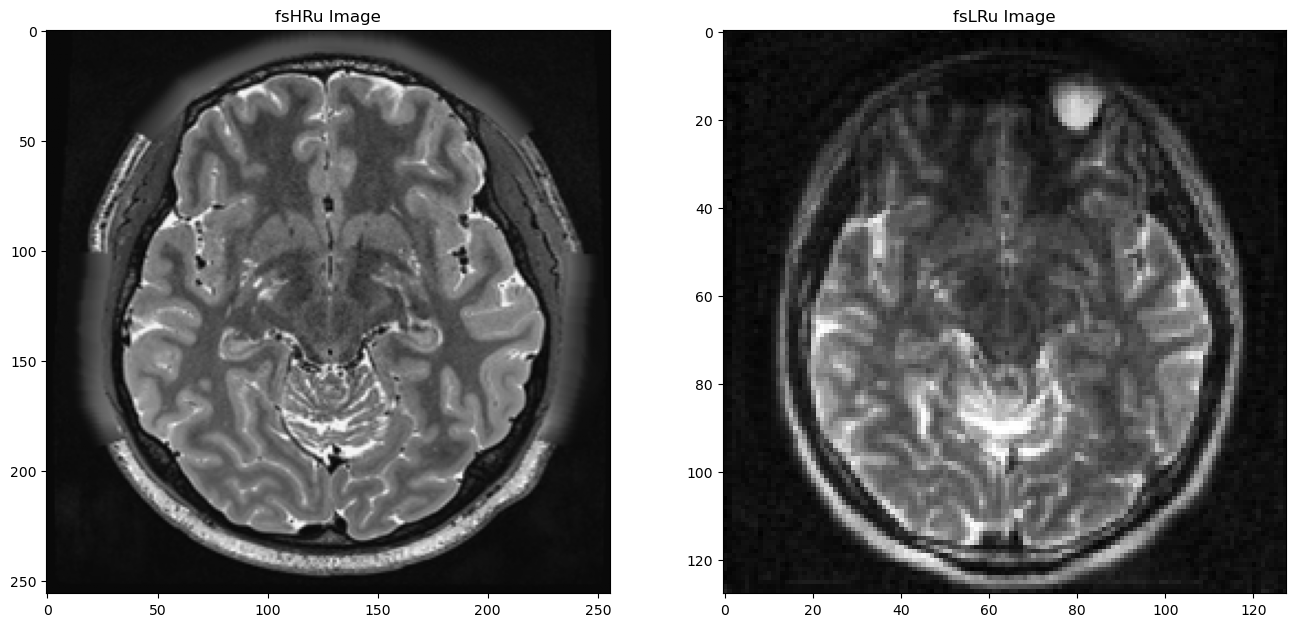

In [42]:
# # Uncomment for visualization if you stored all preprocessed data 
# Select a sample from the fully sampled image domain & print dimensions
sample_fsHRimgP = HR_imagesP[0]; sample_fsLRimgP = LR_imagesP[0]
print(f"Dimensions of - fsHRimgP: {sample_fsHRimgP.shape} || fsLRimgP: {sample_fsLRimgP.shape}")

sample_fsHRimgU = HR_imagesU[0]; sample_fsLRimgU = LR_imagesU[0]
print(f"Dimensions of - fsHRimgU: {sample_fsHRimgU.shape} || fsLRimgU: {sample_fsLRimgU.shape}")

# Compute minVal, maxVal, SSIM & PSNR
print(f"\nminVal of LR: {sample_fsLRimgU.min()} || maxVal of LR: {sample_fsLRimgU.max()}")
print(f"minVal of HR: {sample_fsHRimgU.min()} || maxVal of HR: {sample_fsHRimgU.max()}")

# Plot unpatched images for LR & HR
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1); plt.imshow(sample_fsHRimgU, cmap='gray'); plt.title("fsHRu Image")
plt.subplot(1, 2, 2); plt.imshow(sample_fsLRimgU, cmap='gray'); plt.title("fsLRu Image")
plt.show()

# Plot patched images for LR & HR
# plt.figure(figsize=(16, 8))
# plt.subplot(1, 2, 1); plt.imshow(sample_fsHRimgP[10,10], cmap='gray'); plt.title("fsHRp Image")
# plt.subplot(1, 2, 2); plt.imshow(sample_fsLRimgP[10,10], cmap='gray'); plt.title("fsLRp Image")
# plt.show()

# Dimension Handling, Data Splitting & Sanity Check

**Spatial**

In [43]:
# -----Spatial Domain
# Convert Spatial Data to NumPy Arrays
fsLRimg_Tr = np.array(LR_imagesP); fsHRimg_Tr = np.array(HR_imagesP)
print(f"fsLRimg_Tr shape: {fsLRimg_Tr.shape}, fsHRimg_Tr shape: {fsHRimg_Tr.shape}")

# Reshape Data
X_trn = fsLRimg_Tr.reshape(-1, 1, 32, 32)
y_trn = fsHRimg_Tr.reshape(-1, 1, 64, 64)

# Normalize to [0, 1]
X_trn = (X_trn / 255)  
y_trn = (y_trn / 255)  
print(f"X_trn shape: {X_trn.shape}, y_trn shape: {y_trn.shape}")

fsLRimg_Tr shape: (2920, 7, 7, 32, 32), fsHRimg_Tr shape: (2920, 7, 7, 64, 64)
X_trn shape: (143080, 1, 32, 32), y_trn shape: (143080, 1, 64, 64)


In [44]:
# -----: Training Data
# Split the training data into (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X_trn, y_trn, test_size = 0.2, random_state = 42)

# Display the shapes of the training and fake_test sets
print("X_train shape:", X_train.shape); print("y_train shape:", y_train.shape); print("X_val shape:", X_val.shape); print("y_val shape:", y_val.shape)

print(f"\nminVal of LR: {X_trn.min()}, maxVal of LR: {X_trn.max()}")
print(f"minVal of HR: {y_trn.min()}, maxVal of HR: {y_trn.max()}")

X_train shape: (114464, 1, 32, 32)
y_train shape: (114464, 1, 64, 64)
X_val shape: (28616, 1, 32, 32)
y_val shape: (28616, 1, 64, 64)

minVal of LR: -0.003904142649844289, maxVal of LR: 0.004019667860120535
minVal of HR: -0.004499652422964573, maxVal of HR: 0.004845317918807268


Text(0.5, 1.0, 'y1')

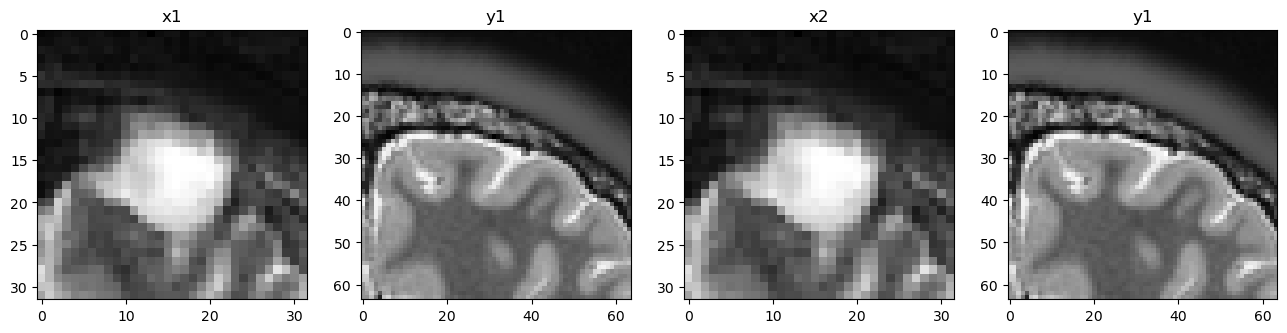

In [45]:
# Plot Visualizations
plt.figure(figsize=(16, 8))
plt.subplot(1, 4, 1); plt.imshow(X_train.squeeze(1)[1000], cmap='gray'); plt.title("x1")
plt.subplot(1, 4, 2); plt.imshow(y_train.squeeze(1)[1000], cmap='gray'); plt.title("y1")
plt.subplot(1, 4, 3); plt.imshow(X_train.squeeze(1)[1000], cmap='gray'); plt.title("x2")
plt.subplot(1, 4, 4); plt.imshow(y_train.squeeze(1)[1000], cmap='gray'); plt.title("y1")

# Create Customized DataLoader

Define PyTorch Dataset

In [46]:
# Define Custom Dataset to Ensure Inputs & Targets are Paired
class ImagesDataset(Dataset):
    def __init__(self, X, y, hflip_prob=0.0, rot_prob=0.0):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.hflip_prob = hflip_prob
        self.rot_prob   = rot_prob

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image  = self.X[idx]  # (C, H, W)
        target = self.y[idx]  # (C, H, W)

        # Apply augmentations if enabled
        if self.hflip_prob > 0.0:
            image, target = hFlip(image, target, self.hflip_prob)

        if self.rot_prob > 0.0:
            image, target = rot90(image, target, self.rot_prob)

        return image, target # Returns (input, target)

Define DataLoaders

In [47]:
# ❗❗❗❗❗
# Holdout Cross-Validation
# Load training and validation datasets
trn_dataset = ImagesDataset(X_train, y_train, hflip_prob=0.5, rot_prob=0.5)
val_dataset = ImagesDataset(X_val, y_val, hflip_prob=0.0, rot_prob=0.0)

# Define DataLoaders
batch_size = 64 # 4, 8, 16
trn_loader = DataLoader(trn_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

# Display shape of a sample training data
for X_batch, y_batch in trn_loader:
    print("X_batch shape:", X_batch.shape)
    print("y_batch shape:", y_batch.shape)
    break

X_batch shape: torch.Size([64, 1, 32, 32])
y_batch shape: torch.Size([64, 1, 64, 64])


Plot Visualization

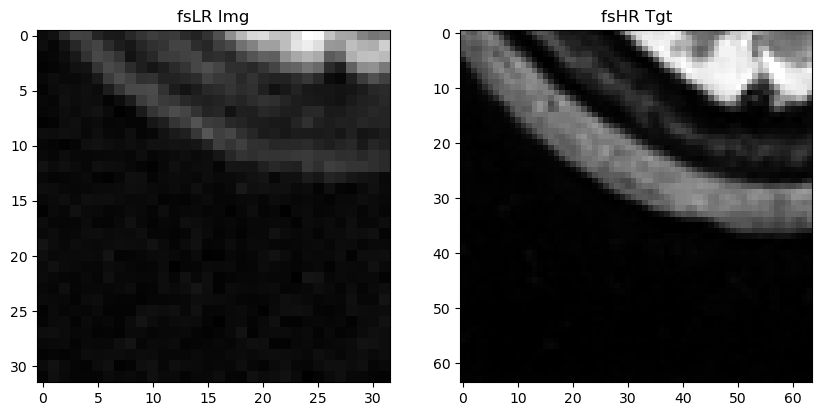

In [48]:
# Fetch one batch from the DataLoader
for X_batch, y_batch in trn_loader:
    break  # Get only the first batch

# Select a random index from the batch
sampleIdx = torch.randint(0, X_batch.shape[0], (1,)).item()

# Extract the sample image and label
Img = X_batch[sampleIdx].squeeze().cpu().numpy() # Remove extra dimensions
Tgt = y_batch[sampleIdx].squeeze().cpu().numpy() # Remove extra dimensions

# Plot the input and target MRI images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(Img, cmap="gray"); plt.title("fsLR Img")
plt.subplot(1, 2, 2); plt.imshow(Tgt, cmap="gray"); plt.title("fsHR Tgt")
plt.show()

___________________

# (C): AI MODEL SETUP - PyTorch FRAMEWORK

**Dictionary Building Block**

In [49]:
class PatchConv(nn.Module):
    def __init__(self, channels: int, tanh: bool = False):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(channels, channels, 1, 1, 0),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 1, 1, 0),
        )
        self.act = nn.Tanh() if tanh else nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.body(x))

**HR Dictionary Generator**

In [50]:
class Dictionary(nn.Module):
    """
    Generates an explicit HR dictionary from random noise.
    Output atoms have spatial size (scale x scale).
    """
    def __init__(self, n_atoms: int, patch_size: int):
        super().__init__()
        assert math.log2(n_atoms).is_integer(), "n_atoms must be a power of 2"

        self.depth = int(math.log2(n_atoms))
        self.patch_size = patch_size

        for k in range(self.depth):
            for i in range(2 ** (k + 1)):
                setattr(
                    self,
                    f"conv_{k + 1}_{i + 1}",
                    PatchConv(patch_size ** 2, tanh=(k == self.depth - 1))
                )

        self.pixel_shuffle = nn.PixelShuffle(patch_size)

        self.code = nn.Sequential(
            nn.Conv2d(n_atoms, n_atoms, patch_size, patch_size, 0, groups=n_atoms),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_atoms, n_atoms, 1, 1, 0),
        )

    def forward(self, x, shuffle=False):
        atoms = [x]

        for k in range(self.depth):
            new_atoms = [None] * (len(atoms) * 2)
            for i in range(len(atoms)):
                left = getattr(self, f"conv_{k + 1}_{i * 2 + 1}")(atoms[i])
                right = getattr(self, f"conv_{k + 1}_{i * 2 + 2}")(atoms[i])

                if k == self.depth - 1:
                    left = self.pixel_shuffle(left)
                    right = self.pixel_shuffle(right)

                new_atoms[i * 2] = left
                new_atoms[i * 2 + 1] = right

            atoms = new_atoms

        if shuffle:
            import random
            random.shuffle(atoms)

        d = torch.cat(atoms, dim=1)   # [B, N, s, s]
        c = self.code(d)              # [B, N, 1, 1]
        return d, c

**Bottleneck Residual Blocks**

In [51]:
class Bottleneck(nn.Module):
    def __init__(self, nf: int):
        super().__init__()
        mid = max(nf // 4, 1)
        self.block = nn.Sequential(
            nn.Conv2d(nf, mid, 1, 1, 0),
            nn.BatchNorm2d(mid),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid, mid, 3, 1, 1),
            nn.BatchNorm2d(mid),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid, nf, 1, 1, 0),
            nn.BatchNorm2d(nf),
        )

    def forward(self, x):
        return x + self.block(x)


class BottleneckGroup(nn.Module):
    def __init__(self, nf: int, n_blocks: int):
        super().__init__()
        layers = [Bottleneck(nf) for _ in range(n_blocks)]
        layers.append(nn.Conv2d(nf, nf, 1, 1, 0))
        self.group = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.group(x)

**Reduced UNet++ Blocks**

In [52]:
class ConvBlock(nn.Module):
    def __init__(self, in_c: int, mid_c: int, out_c: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, mid_c, 3, 1, 1),
            nn.BatchNorm2d(mid_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid_c, out_c, 3, 1, 1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

**Nested UNet Feature Extractor**

In [53]:
class NestedUNet(nn.Module):
    def __init__(self, nfs, in_channels=1):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        self.initial = nn.Conv2d(in_channels, nfs[0] // 2, 3, 1, 1)

        self.conv0_0 = ConvBlock(in_channels, nfs[0], nfs[0])
        self.conv1_0 = ConvBlock(nfs[0], nfs[1], nfs[1])
        self.conv2_0 = ConvBlock(nfs[1], nfs[2], nfs[2])
        self.conv3_0 = ConvBlock(nfs[2], nfs[3], nfs[3])

        self.conv0_1 = ConvBlock(nfs[0] + nfs[1], nfs[0], nfs[0])
        self.conv1_1 = ConvBlock(nfs[1] + nfs[2], nfs[1], nfs[1])
        self.conv2_1 = ConvBlock(nfs[2] + nfs[3], nfs[2], nfs[2])

        self.conv0_2 = ConvBlock(nfs[0] * 2 + nfs[1], nfs[0], nfs[0])
        self.conv1_2 = ConvBlock(nfs[1] * 2 + nfs[2], nfs[1], nfs[1])

        self.conv0_3 = ConvBlock(nfs[0] * 3 + nfs[1], nfs[0], nfs[0])

        self.final = nn.Conv2d(nfs[0] + nfs[0] // 2, nfs[0], 3, 1, 1)

    def forward(self, x):
        xini = self.initial(x)

        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], dim=1))

        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], dim=1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], dim=1))

        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], dim=1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], dim=1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], dim=1))

        return self.final(torch.cat([x0_3, xini], dim=1))

**Single-channel MRI SRDD Model**

In [54]:
class MRI_SRDD(nn.Module):
    def __init__(self, scale=2, n_atoms=64, in_channels=1):
        super().__init__()
        self.scale = scale
        self.n_atoms = n_atoms

        nfs = [n_atoms, n_atoms * 2, n_atoms * 4, n_atoms * 8]

        self.dict_gen = Dictionary(n_atoms=n_atoms, patch_size=scale)
        self.body = NestedUNet(nfs=nfs, in_channels=in_channels)

        self.tail = nn.Sequential(
            nn.Conv2d(nfs[0] + n_atoms, nfs[0] + n_atoms, 1, 1, 0),
            BottleneckGroup(nfs[0] + n_atoms, n_blocks=10),
            nn.Conv2d(nfs[0] + n_atoms, n_atoms, 1, 1, 0),
            nn.Softmax(dim=1),
        )

        self.comp = nn.Sequential(
            nn.Conv2d(n_atoms, n_atoms, 2, 1, 0),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_atoms, n_atoms, 1, 1, 0),
            nn.Softmax(dim=1),
        )

        self.fuse = nn.Conv2d(2, 1, 5, 1, 0)

    def forward(self, x, stored_dict=None, stored_code=None, shuffle=False):
        """
        x: [B, 1, H, W]
        output: [B, 1, scale*H, scale*W]
        """
        b, _, h, w = x.shape

        # Base upsample branch
        x_base = F.interpolate(x, scale_factor=self.scale, mode="bicubic", align_corners=False)

        # Dictionary
        if stored_dict is None or stored_code is None:
            z = torch.randn(b, self.scale ** 2, 1, 1, device=x.device)
            d, c = self.dict_gen(z, shuffle=shuffle)   # d: [B,N,s,s], c:[B,N,1,1]
            d = d.repeat(1, 1, h, w)                   # [B,N,sH,sW] after spatial repeat
            c = c.repeat(1, 1, h, w)                   # [B,N,H,W]
        else:
            d, c = stored_dict, stored_code

        # Feature extraction + coefficient prediction
        feat = self.body(x)                            # [B,n_atoms,H,W]
        pred = self.tail(torch.cat([feat, c], dim=1)) # [B,N,H,W]
        comp = self.comp(pred)                         # [B,N,H-1,W-1] effectively after conv2d k=2

        # Upsample coefficient maps
        pred_up = F.interpolate(pred, scale_factor=self.scale, mode="nearest")
        comp_up = F.interpolate(comp, scale_factor=self.scale, mode="nearest")

        # Main reconstruction
        x_main = torch.sum(pred_up * d, dim=1, keepdim=True)

        # Complementary reconstruction
        y_comp = torch.sum(comp_up * d[:, :, self.scale:, self.scale:], dim=1, keepdim=True)

        # Boundary compensation
        m = self.scale // 2
        if x_main.shape[-1] > 2 * (m + 2) + 4 and x_main.shape[-2] > 2 * (m + 2) + 4:
            fused = self.fuse(torch.cat([x_main[:, :, m:-m, m:-m], y_comp], dim=1))
            x_main[:, :, m + 2:-m - 2, m + 2:-m - 2] = fused

        # Residual add
        out = x_main + x_base

        atom_vis = d[:1, :, :self.scale, :self.scale]
        code_vis = c[:1, :, :1, :1]

        return out, atom_vis, code_vis

**SRDDL Architecture**

**Spatial**

In [55]:
# Assuming 'model' is your built PyTorch model
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using {device} device")
model = MRI_SRDD(scale=2, n_atoms=64, in_channels=1).to(device)
print(model) # Print the model architecture

# Calculate the total number of parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {num_params}")

for name, param in model.named_parameters():
    print(name, param.numel())

Using cuda device
MRI_SRDD(
  (dict_gen): Dictionary(
    (conv_1_1): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
      )
      (act): ReLU(inplace=True)
    )
    (conv_1_2): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
      )
      (act): ReLU(inplace=True)
    )
    (conv_2_1): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
      )
      (act): ReLU(inplace=True)
    )
    (conv_2_2): PatchConv(
      (body): Sequential(
        (0): Conv2d(4, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 4, kernel_size=(1,

# Optimizing the Model Parameters

In [56]:
# Set up the optimizer
def build_optimizer(model, lr=1e-4, dict_lr=1e-3):
    optimizer = torch.optim.Adam([{"params": model.dict_gen.parameters(), "lr": dict_lr}, {"params": model.body.parameters(), "lr": lr}, {"params": model.tail.parameters(), "lr": lr}, {"params": model.comp.parameters(), "lr": lr}, {"params": model.fuse.parameters(), "lr": lr},], betas=(0.9, 0.999), eps=1e-8,)
    return optimizer

optimizer = build_optimizer(model)
criterion = nn.L1Loss()

# Model Training

# Holdout Cross-Validation

# Fine-tuning

In [57]:
# Fine-tuning function
def finetune_mri_srdd(model, trn_loader, val_loader, epochs, device, pretrained_path, lr=1e-4, dict_lr=1e-3, freeze_dict_epoch=None, checkpoint_path=checkpoint_path, freeze_dictionary_from_start=False):
    
    # Load pretrained weights
    checkpoint = torch.load(pretrained_path, map_location=device)

    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
        print(f"Loaded pretrained model from: {pretrained_path}")
        if "epoch" in checkpoint:
            print(f"Pretrained checkpoint epoch: {checkpoint['epoch']}")
        if "val_loss" in checkpoint:
            print(f"Pretrained checkpoint val loss: {checkpoint['val_loss']:.6f}")
    else:
        model.load_state_dict(checkpoint)
        print(f"Loaded raw pretrained weights from: {pretrained_path}")

    # Optimizer & loss
    optimizer = build_optimizer(model, lr=lr, dict_lr=dict_lr)
    criterion = nn.L1Loss()

    # Tracking best model & history
    best_val_loss = float("inf")
    history = {"train_loss": [], "val_loss": []}

    model.to(device)

    # Optional: freeze dictionary from the start
    if freeze_dictionary_from_start:
        for p in model.dict_gen.parameters():
            p.requires_grad = False
        print("Dictionary frozen from start of fine-tuning.")

    # Fine-tuning Loop
    for epoch in range(epochs):

        # Set model to training mode
        model.train()
        running_train_loss = 0.0

        # Optional: freeze dictionary later
        if freeze_dict_epoch is not None and epoch == freeze_dict_epoch:
            for p in model.dict_gen.parameters():
                p.requires_grad = False
            print(f"Dictionary frozen at fine-tuning epoch {epoch}")

        # Training Phase
        for X_batch, y_batch in trn_loader:
            X_batch = X_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            # During fine-tuning, usually no need for atom shuffling
            pred, _, _ = model(X_batch, shuffle=False)

            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        train_loss = running_train_loss / len(trn_loader)

        # Validation Phase
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device).float()
                y_batch = y_batch.to(device).float()

                pred, _, _ = model(X_batch, shuffle=False)
                val_loss_batch = criterion(pred, y_batch)
                running_val_loss += val_loss_batch.item()

        val_loss = running_val_loss / len(val_loader)

        # Store loss history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # Print progress
        print(f"Fine-tune Epoch [{epoch+1}/{epochs}] || " f"Train Loss: {train_loss:.6f} || " f"Val Loss: {val_loss:.6f}")

        # Save best fine-tuned model
        if val_loss < best_val_loss:
            best_val_loss = val_loss

            os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

            torch.save({"epoch": epoch + 1, "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "train_loss": train_loss, "val_loss": val_loss,}, checkpoint_path,)

            print(f"Best fine-tuned model saved to: {checkpoint_path}")

    print(f"Fine-tuning complete. Best Val Loss: {best_val_loss:.6f}")
    return model, history

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = MRI_SRDD(scale=2, n_atoms=64, in_channels=1).to(device)

model, history = finetune_mri_srdd(model=model, trn_loader=trn_loader, val_loader=val_loader, epochs=EPOCH_COUNT, device=device, pretrained_path=pretrained_path, lr=1e-4, dict_lr=1e-3, freeze_dict_epoch=20, checkpoint_path=checkpoint_path, freeze_dictionary_from_start=False)

Loaded pretrained model from: G:\LF-7T-CycleGAN\benchmarks\SRDDL\weight\srdd150E.pt
Pretrained checkpoint epoch: 148
Pretrained checkpoint val loss: 0.006329
Fine-tune Epoch [1/30] || Train Loss: 0.000682 || Val Loss: 0.000528
Best fine-tuned model saved to: G:\LF-7T-CycleGAN\benchmarks\SRDDL\weight\T2w-checkpoints-full-dataset-run.pt
Fine-tune Epoch [2/30] || Train Loss: 0.000540 || Val Loss: 0.000470
Best fine-tuned model saved to: G:\LF-7T-CycleGAN\benchmarks\SRDDL\weight\T2w-checkpoints-full-dataset-run.pt
Fine-tune Epoch [3/30] || Train Loss: 0.000494 || Val Loss: 0.000440
Best fine-tuned model saved to: G:\LF-7T-CycleGAN\benchmarks\SRDDL\weight\T2w-checkpoints-full-dataset-run.pt
Fine-tune Epoch [4/30] || Train Loss: 0.000467 || Val Loss: 0.000433
Best fine-tuned model saved to: G:\LF-7T-CycleGAN\benchmarks\SRDDL\weight\T2w-checkpoints-full-dataset-run.pt
Fine-tune Epoch [5/30] || Train Loss: 0.000446 || Val Loss: 0.000406
Best fine-tuned model saved to: G:\LF-7T-CycleGAN\benchma

# Plot Learning Curves

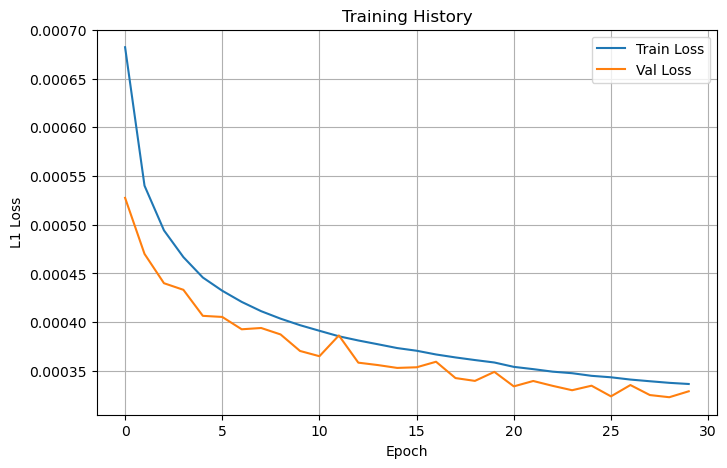

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training History")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
import os, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image

ROOT = r"S:\\Edward\\MRI data\\Radiologist Review Dataset"
DIRS = ["Real-LF", "CycleGAN", "SRDDL", "LF-7T-CycleGAN"]
LBLS = ["Real LF", "CycleGAN", "SR-DDL", "LF-7T-CycleGAN"]
PATCH = (0.40, 0.35, 0.22, 0.22)

scans = sorted(os.listdir(os.path.join(ROOT, DIRS[0])))
fig, axes = plt.subplots(len(scans)*2, 4, figsize=(12, len(scans)*5), dpi=300)

for s, scan in enumerate(scans):
    for i, d in enumerate(DIRS):
        arr = np.array(Image.open(os.path.join(ROOT, d, scan)).convert("L")) / 255.0
        H, W = arr.shape
        x0, y0, pw, ph = int(PATCH[0]*W), int(PATCH[1]*H), int(PATCH[2]*W), int(PATCH[3]*H)

        ax = axes[s*2, i]
        ax.imshow(arr, cmap="gray", vmin=0, vmax=1)
        ax.add_patch(patches.Rectangle((x0,y0), pw, ph, lw=1, edgecolor="yellow", facecolor="none"))
        ax.axis("off")
        if s == 0: ax.set_title(LBLS[i], fontsize=7)

        ax2 = axes[s*2+1, i]
        ax2.imshow(arr[y0:y0+ph, x0:x0+pw], cmap="gray", vmin=0, vmax=1)
        ax2.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(ROOT, "comparison.png"), bbox_inches="tight")
plt.show()

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'S:\\\\Edward\\\\MRI data\\\\Radiologist Review Dataset\\Real-LF'

__________________________

# **(D): MODEL EVALUATION**

See inference code!

__________________________

# **APPENDIX**